In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
df = pd.read_csv("bitcointest.csv")
df.head()

,Unnamed: 0,datetime,marketcap,priceBtc,priceUsd,volume,sentiment_positive_total,sentiment_positive_telegram,sentiment_positive_professional_traders_chat,sentiment_positive_reddit,...,sentiment_negative_twitter,sentiment_negative_bitcointalk,social_volume_total,social_volume_telegram,social_volume_professional_traders_chat,social_volume_reddit,social_volume_discord,social_volume_twitter,social_volume_bitcointalk,priceDirection
0,1,2021-02-01 00:05:00+00:00,6.096948e+11,1.0,32606.943250,5.221589e+10,10.018179,0.821015,0.000000,9.662313,...,3.451326,0.84954,50.0,7.0,0.0,42.0,13.0,14.0,2.0,negative
1,2,2021-02-01 00:10:00+00:00,6.070084e+11,1.0,32474.394205,5.241600e+10,8.810097,1.684945,0.000000,8.563550,...,2.197357,0.00000,49.0,7.0,0.0,51.0,7.0,16.0,4.0,negative
2,3,2021-02-01 00:15:00+00:00,6.045409e+11,1.0,32541.784840,5.265144e+10,9.887896,0.000000,1.645055,8.670272,...,4.796923,0.00000,48.0,5.0,3.0,42.0,12.0,21.0,2.0,positive
3,4,2021-02-01 00:20:00+00:00,6.057954e+11,1.0,32387.177898,5.251510e+10,8.856743,0.735735,0.000000,6.025929,...,1.659990,0.00000,59.0,7.0,0.0,49.0,9.0,18.0,3.0,negative
4,5,2021-02-01 00:25:00+00:00,6.029173e+11,1.0,32446.571378,5.272158e+10,4.626992,0.000000,0.774311,2.368803,...,2.456149,0.00000,54.0,8.0,1.0,40.0,10.0,14.0,2.0,positive


<AxesSubplot:>

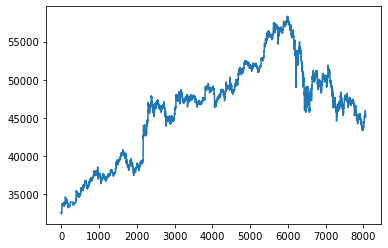

In [3]:
#plt.style.use('ggplot')
df['priceUsd'].plot()

In [4]:
x = df.iloc[:, 7:-1]
y = df.iloc[:, 4:5]

In [5]:
#y.reshape(-1,1)
#y.head()

In [6]:
mm = MinMaxScaler()
ss = StandardScaler()


x_ss = ss.fit_transform(x)
y_mm = mm.fit_transform(y) 

In [7]:
x_train = x_ss[:5000, :]
x_test = x_ss[5000:,:]
y_train = y_mm[:5000, :]
y_test = y_mm[5000:, :]

In [8]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(5000, 20) (5000, 1)
(3063, 20) (3063, 1)


In [9]:
x_train_tensors = Variable(torch.Tensor(x_train))
x_test_tensors = Variable(torch.Tensor(x_test))
y_train_tensors = Variable(torch.Tensor(y_train))
y_test_tensors = Variable(torch.Tensor(y_test)) 

In [10]:
x_train_tensors_final = torch.reshape(x_train_tensors,   (x_train_tensors.shape[0], 1, x_train_tensors.shape[1]))
x_test_tensors_final = torch.reshape(x_test_tensors,  (x_test_tensors.shape[0], 1, x_test_tensors.shape[1])) 
print("Training Shape", x_train_tensors_final.shape, y_train_tensors.shape)
print("Testing Shape", x_test_tensors_final.shape, y_test_tensors.shape) 

Training Shape torch.Size([5000, 1, 20]) torch.Size([5000, 1])
Testing Shape torch.Size([3063, 1, 20]) torch.Size([3063, 1])


In [11]:
class LSTM1(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
        super(LSTM1, self).__init__()
        self.num_classes = num_classes #number of classes
        self.num_layers = num_layers #number of layers
        self.input_size = input_size #input size
        self.hidden_size = hidden_size #hidden state
        self.seq_length = seq_length #sequence length

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True) #lstm
        self.fc_1 =  nn.Linear(hidden_size, 128) #fully connected 1
        self.fc = nn.Linear(128, num_classes) #fully connected last layer

        self.relu = nn.ReLU()
    
    def forward(self,x):
        h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #hidden state
        c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #internal state
        # Propagate input through LSTM
        output, (hn, cn) = self.lstm(x, (h_0, c_0)) #lstm with input, hidden, and internal state
        hn = hn.view(-1, self.hidden_size) #reshaping the data for Dense layer next
        out = self.relu(hn)
        out = self.fc_1(out) #first Dense
        out = self.relu(out) #relu
        out = self.fc(out) #Final Output
        return out

In [12]:
num_epochs = 2000 #1000 epochs
learning_rate = 0.001 #0.001 lr

input_size = 20 #number of features
hidden_size = 40 #number of features in hidden state
num_layers = 1 #number of stacked lstm layers

num_classes = 1 #number of output classes 

In [13]:
lstm1 = LSTM1(num_classes, input_size, hidden_size, num_layers, x_train_tensors_final.shape[1]) #our lstm class 

In [14]:
criterion = torch.nn.MSELoss()  # mean-squared error for regression
optimizer = torch.optim.Adam(lstm1.parameters(), lr=learning_rate) 

In [15]:
for epoch in range(num_epochs):
  outputs = lstm1.forward(x_train_tensors_final) #forward pass
  optimizer.zero_grad() #caluclate the gradient, manually setting to 0
 
  # obtain the loss function
  loss = criterion(outputs, y_train_tensors)
 
  loss.backward() #calculates the loss of the loss function
 
  optimizer.step() #improve from loss, i.e backprop
  if epoch % 100 == 0:
    print("Epoch: %d, loss: %1.5f" % (epoch, loss.item())) 

Epoch: 0, loss: 0.25242
Epoch: 100, loss: 0.02556
Epoch: 200, loss: 0.02149
Epoch: 300, loss: 0.01907
Epoch: 400, loss: 0.01727
Epoch: 500, loss: 0.01566
Epoch: 600, loss: 0.01429
Epoch: 700, loss: 0.01315
Epoch: 800, loss: 0.01211
Epoch: 900, loss: 0.01116
Epoch: 1000, loss: 0.01030
Epoch: 1100, loss: 0.00960
Epoch: 1200, loss: 0.00904
Epoch: 1300, loss: 0.00855
Epoch: 1400, loss: 0.00812
Epoch: 1500, loss: 0.00772
Epoch: 1600, loss: 0.00739
Epoch: 1700, loss: 0.00710
Epoch: 1800, loss: 0.00680
Epoch: 1900, loss: 0.00655


In [16]:
df_x_ss = ss.transform(df.iloc[:, 7:-1]) #old transformers
df_y_mm = mm.transform(df.iloc[:, 4:5]) #old transformers

df_x_ss = Variable(torch.Tensor(df_x_ss)) #converting to Tensors
df_y_mm = Variable(torch.Tensor(df_y_mm))
#reshaping the dataset
df_x_ss = torch.reshape(df_x_ss, (df_x_ss.shape[0], 1, df_x_ss.shape[1]))

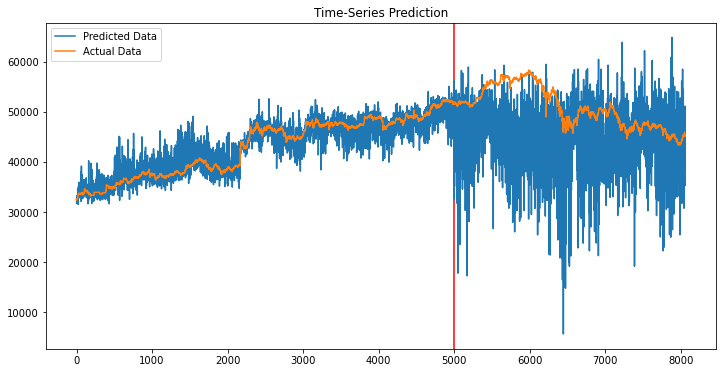

In [17]:
train_predict = lstm1(df_x_ss)#forward pass
data_predict = train_predict.data.numpy() #numpy conversion
dataY_plot = df_y_mm.data.numpy()

data_predict = mm.inverse_transform(data_predict) #reverse transformation
dataY_plot = mm.inverse_transform(dataY_plot)
plt.figure(figsize=(12,6)) #plotting
plt.axvline(x=5000, c='r', linestyle='-') #size of the training set

plt.plot(data_predict, label='Predicted Data') #predicted plot
plt.plot(dataY_plot, label='Actual Data') #actual plot

plt.title('Time-Series Prediction')
plt.legend()
plt.show() 